<a href="https://colab.research.google.com/github/nandinisingh66/CSET343/blob/main/AIinHealtcare2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -q https://www.kaggle.com/api/v1/datasets/download/andrewmvd/heart-failure-clinical-data -O heart_failure.zip

!unzip -o heart_failure.zip

!ls

Archive:  heart_failure.zip
  inflating: heart_failure_clinical_records_dataset.csv  
heart_failure_clinical_records_dataset.csv  heart_failure.zip  sample_data


In [2]:
import pandas as pd

df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [4]:
df.info()
df.describe()
print("Number of duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
Number of duplicat

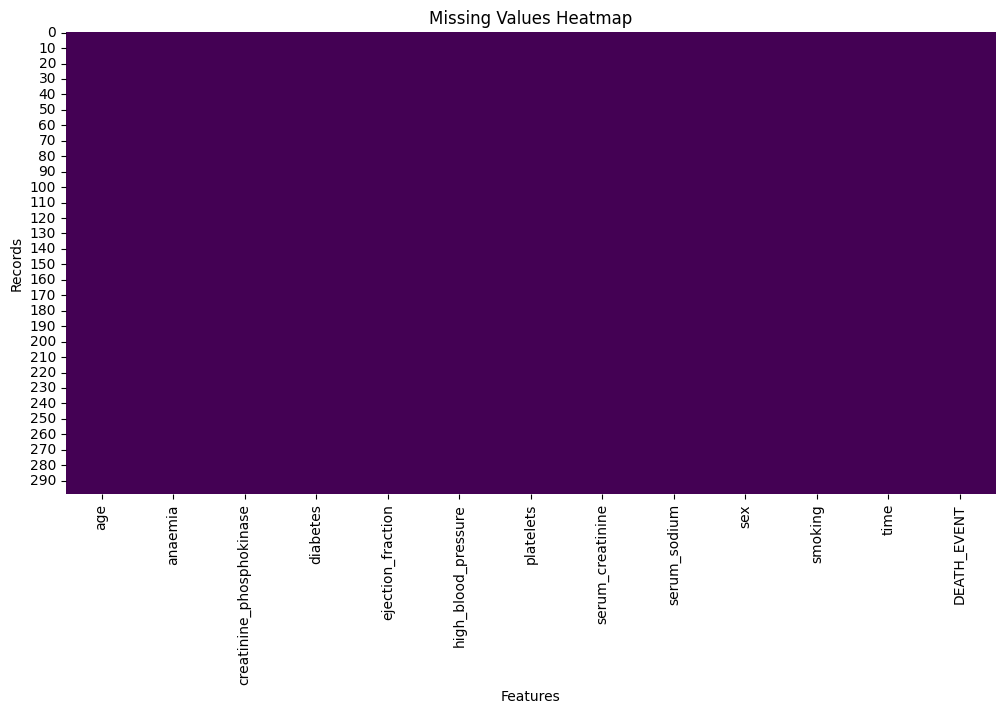

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

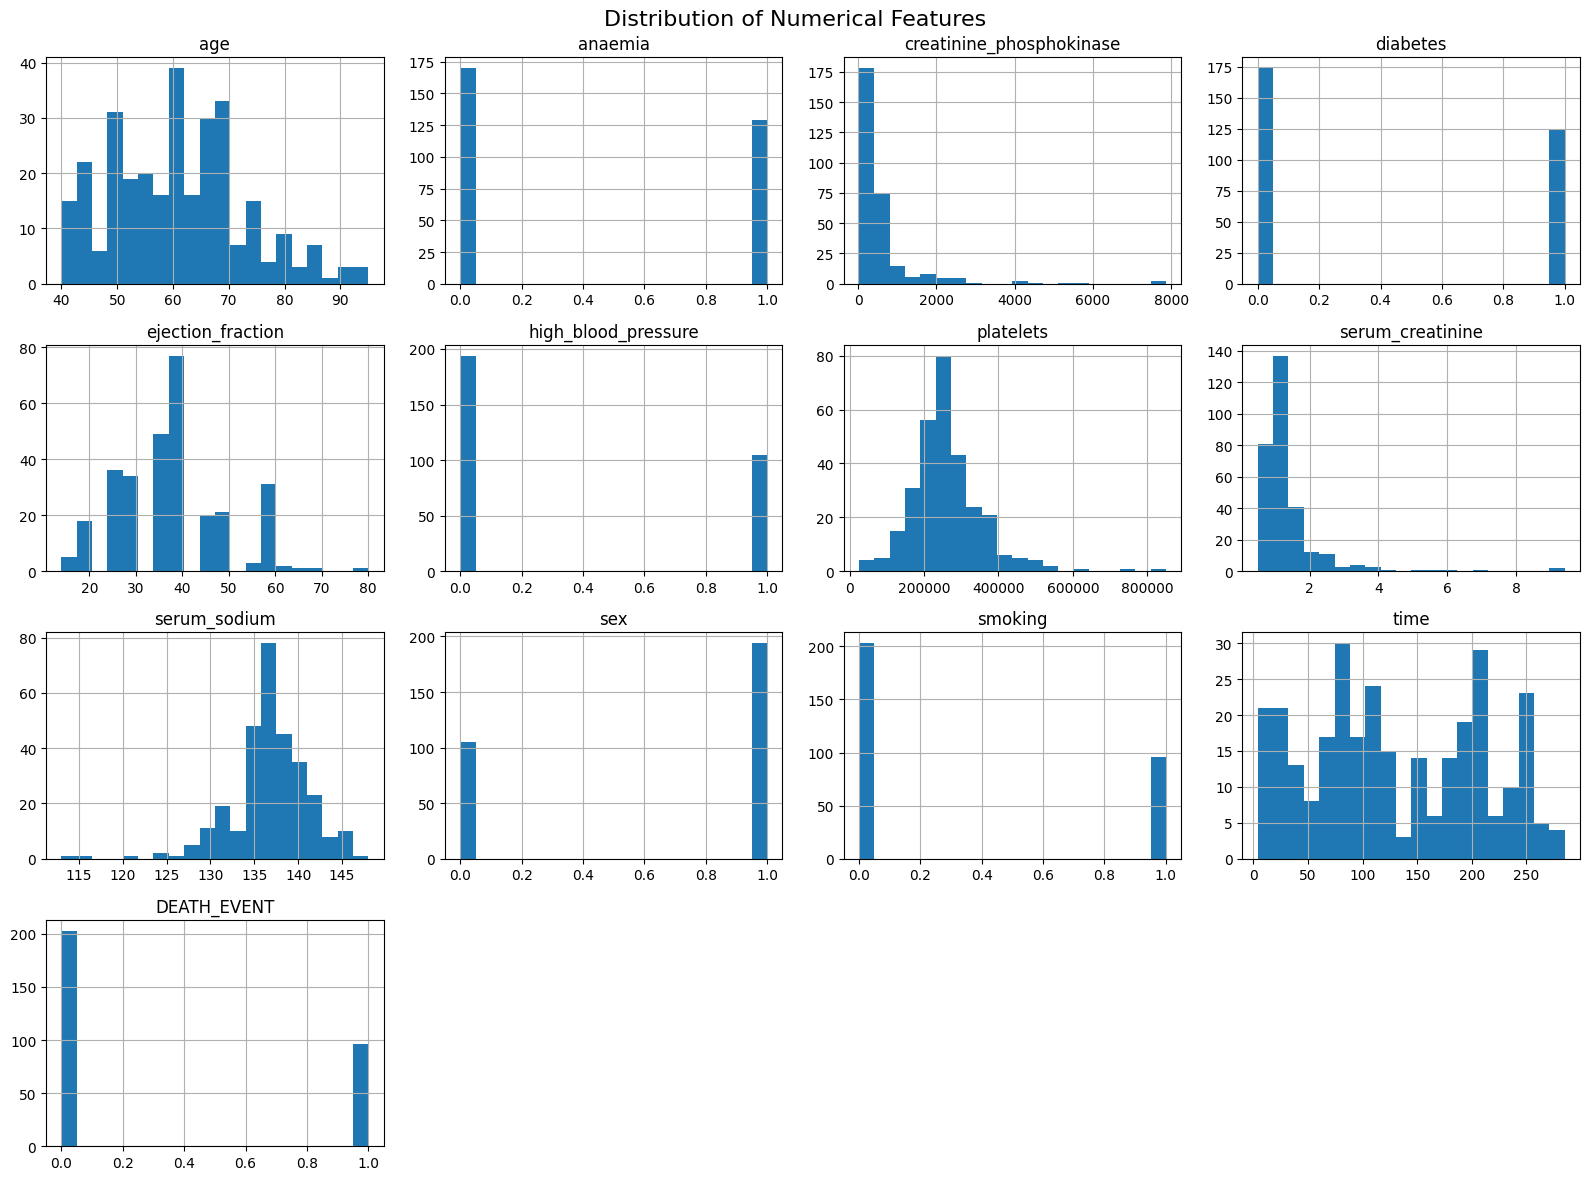

In [6]:

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

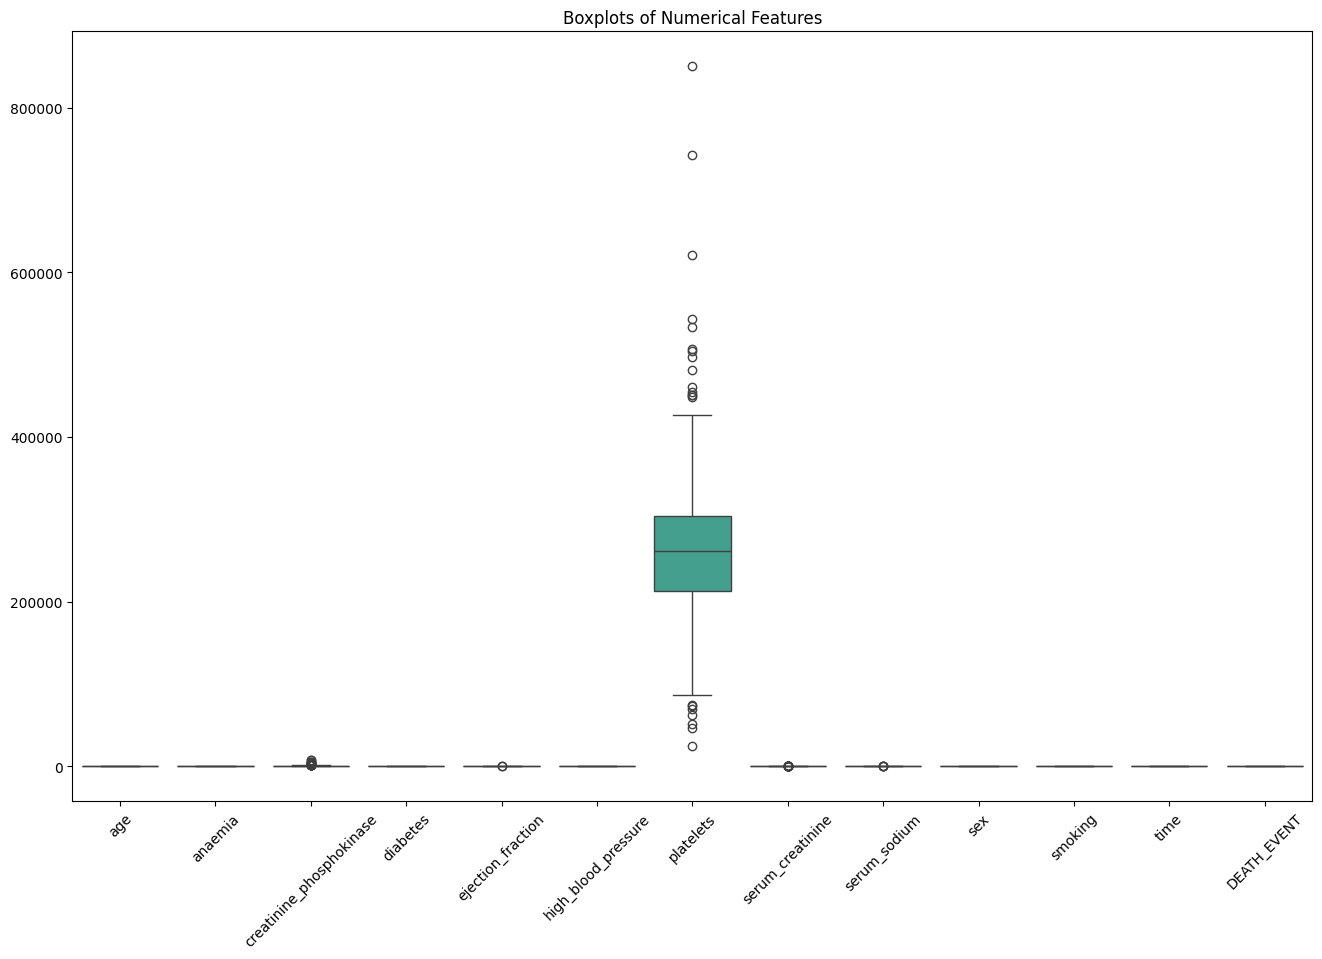

In [7]:
plt.figure(figsize=(16, 10))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplots of Numerical Features")
plt.xticks(rotation=45)
plt.show()

In [8]:
cleaned_df = df.copy()

numerical_columns = cleaned_df.select_dtypes(
    include=["int64", "float64"]
).columns


categorical_columns = cleaned_df.select_dtypes(
    include=["object", "category"]
).columns

for col in numerical_columns:
    if cleaned_df[col].isnull().sum() > 0:
        cleaned_df[col] = cleaned_df[col].fillna(
            cleaned_df[col].median()
        )

for col in categorical_columns:
    if cleaned_df[col].isnull().sum() > 0:
        cleaned_df[col] = cleaned_df[col].fillna(
            cleaned_df[col].mode()[0]
        )

print("Missing values after imputation:")
print(cleaned_df.isnull().sum())
print("Total missing values:", cleaned_df.isnull().sum().sum())

Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
Total missing values: 0


In [9]:
# Numerical clinical features for outlier detection
outlier_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

before_outliers = cleaned_df.shape[0]

outlier_mask = pd.Series(True, index=cleaned_df.index)

for col in outlier_columns:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask &= (
        (cleaned_df[col] >= lower_bound) &
        (cleaned_df[col] <= upper_bound)
    )

cleaned_df = cleaned_df[outlier_mask].copy()

after_outliers = cleaned_df.shape[0]

print("Rows before outlier removal:", before_outliers)
print("Rows after outlier removal:", after_outliers)
print("Outliers removed:", before_outliers - after_outliers)

Rows before outlier removal: 299
Rows after outlier removal: 224
Outliers removed: 75


In [10]:

invalid_age_count = (cleaned_df["age"] <= 0).sum()

print("Invalid age values:", invalid_age_count)

cleaned_df.loc[cleaned_df["age"] <= 0, "age"] = float("nan")

cleaned_df["age"] = cleaned_df["age"].fillna(
    cleaned_df["age"].median()
)

print("Invalid ages after correction:",
      (cleaned_df["age"] <= 0).sum())

Invalid age values: 0
Invalid ages after correction: 0


In [11]:
# Check for invalid negative values
columns_to_check = [
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

for col in columns_to_check:
    print(
        col,
        "negative values:",
        (cleaned_df[col] < 0).sum()
    )

creatinine_phosphokinase negative values: 0
ejection_fraction negative values: 0
platelets negative values: 0
serum_creatinine negative values: 0
serum_sodium negative values: 0


In [12]:
# Create age groups
def categorize_age(age):
    if age < 40:
        return "<40"
    elif age <= 60:
        return "40-60"
    else:
        return ">60"

cleaned_df["age_group"] = cleaned_df["age"].apply(categorize_age)

cleaned_df[["age", "age_group"]].head(10)

,age,age_group
0,75.0,>60
2,65.0,>60
3,50.0,40-60
5,90.0,>60
6,75.0,>60
8,65.0,>60
11,62.0,>60
12,45.0,40-60
13,50.0,40-60
14,49.0,40-60


In [13]:

cleaned_df["raw_risk_score"] = (
    cleaned_df["ejection_fraction"] *
    cleaned_df["serum_creatinine"]
)

risk_min = cleaned_df["raw_risk_score"].min()
risk_max = cleaned_df["raw_risk_score"].max()

cleaned_df["risk_score"] = (
    (cleaned_df["raw_risk_score"] - risk_min) /
    (risk_max - risk_min)
)


cleaned_df.drop(columns=["raw_risk_score"], inplace=True)

cleaned_df[[
    "ejection_fraction",
    "serum_creatinine",
    "risk_score"
]].head(10)

,ejection_fraction,serum_creatinine,risk_score
0,20,1.9,0.310545
2,20,1.3,0.171495
3,20,1.9,0.310545
5,40,2.1,0.843569
6,15,1.2,0.078795
8,65,1.5,1.000000
11,25,0.9,0.130939
12,30,1.1,0.252607
13,38,1.1,0.354577
14,30,1.0,0.217845


In [14]:
# One-hot encode categorical variables
categorical_features = [
    "sex",
    "smoking",
    "age_group"
]

encoded_df = pd.get_dummies(
    cleaned_df,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

encoded_df.head()
print("Columns after encoding:")
print(encoded_df.columns.tolist())

Columns after encoding:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'time', 'DEATH_EVENT', 'risk_score', 'sex_0', 'sex_1', 'smoking_0', 'smoking_1', 'age_group_40-60', 'age_group_>60']


In [15]:
from sklearn.preprocessing import MinMaxScaler

scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

scaler = MinMaxScaler()

encoded_df[scale_columns] = scaler.fit_transform(
    encoded_df[scale_columns]
)

encoded_df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0,smoking_1,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,0.000000,1,0.310545,0,1,1,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,0.010676,1,0.171495,0,1,0,1,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,0.010676,1,0.310545,0,1,1,0,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,0.014235,1,0.843569,0,1,0,1,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,0.021352,1,0.078795,0,1,1,0,0,1


In [16]:
print("Minimum values:")
print(encoded_df[scale_columns].min())

print("\nMaximum values:")
print(encoded_df[scale_columns].max())

Minimum values:
age                         0.0
creatinine_phosphokinase    0.0
ejection_fraction           0.0
platelets                   0.0
serum_creatinine            0.0
serum_sodium                0.0
time                        0.0
dtype: float64

Maximum values:
age                         1.0
creatinine_phosphokinase    1.0
ejection_fraction           1.0
platelets                   1.0
serum_creatinine            1.0
serum_sodium                1.0
time                        1.0
dtype: float64


In [17]:

comparison_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium"
]

before_stats = pd.DataFrame({
    "Mean": df[comparison_columns].mean(),
    "Median": df[comparison_columns].median(),
    "Standard Deviation": df[comparison_columns].std()
})

after_stats = pd.DataFrame({
    "Mean": cleaned_df[comparison_columns].mean(),
    "Median": cleaned_df[comparison_columns].median(),
    "Standard Deviation": cleaned_df[comparison_columns].std()
})

print("Statistics Before Cleaning:")
display(before_stats)

print("\nStatistics After Cleaning:")
display(after_stats)

Statistics Before Cleaning:


,Mean,Median,Standard Deviation
age,60.833893,60.0,11.894809
creatinine_phosphokinase,581.839465,250.0,970.287881
ejection_fraction,38.083612,38.0,11.834841
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477



Statistics After Cleaning:


,Mean,Median,Standard Deviation
age,60.809527,60.0,11.946085
creatinine_phosphokinase,336.941964,212.0,279.521085
ejection_fraction,38.178571,38.0,11.710801
platelets,255865.190045,262500.0,67153.749051
serum_creatinine,1.128571,1.1,0.327794
serum_sodium,137.044643,137.0,3.806740


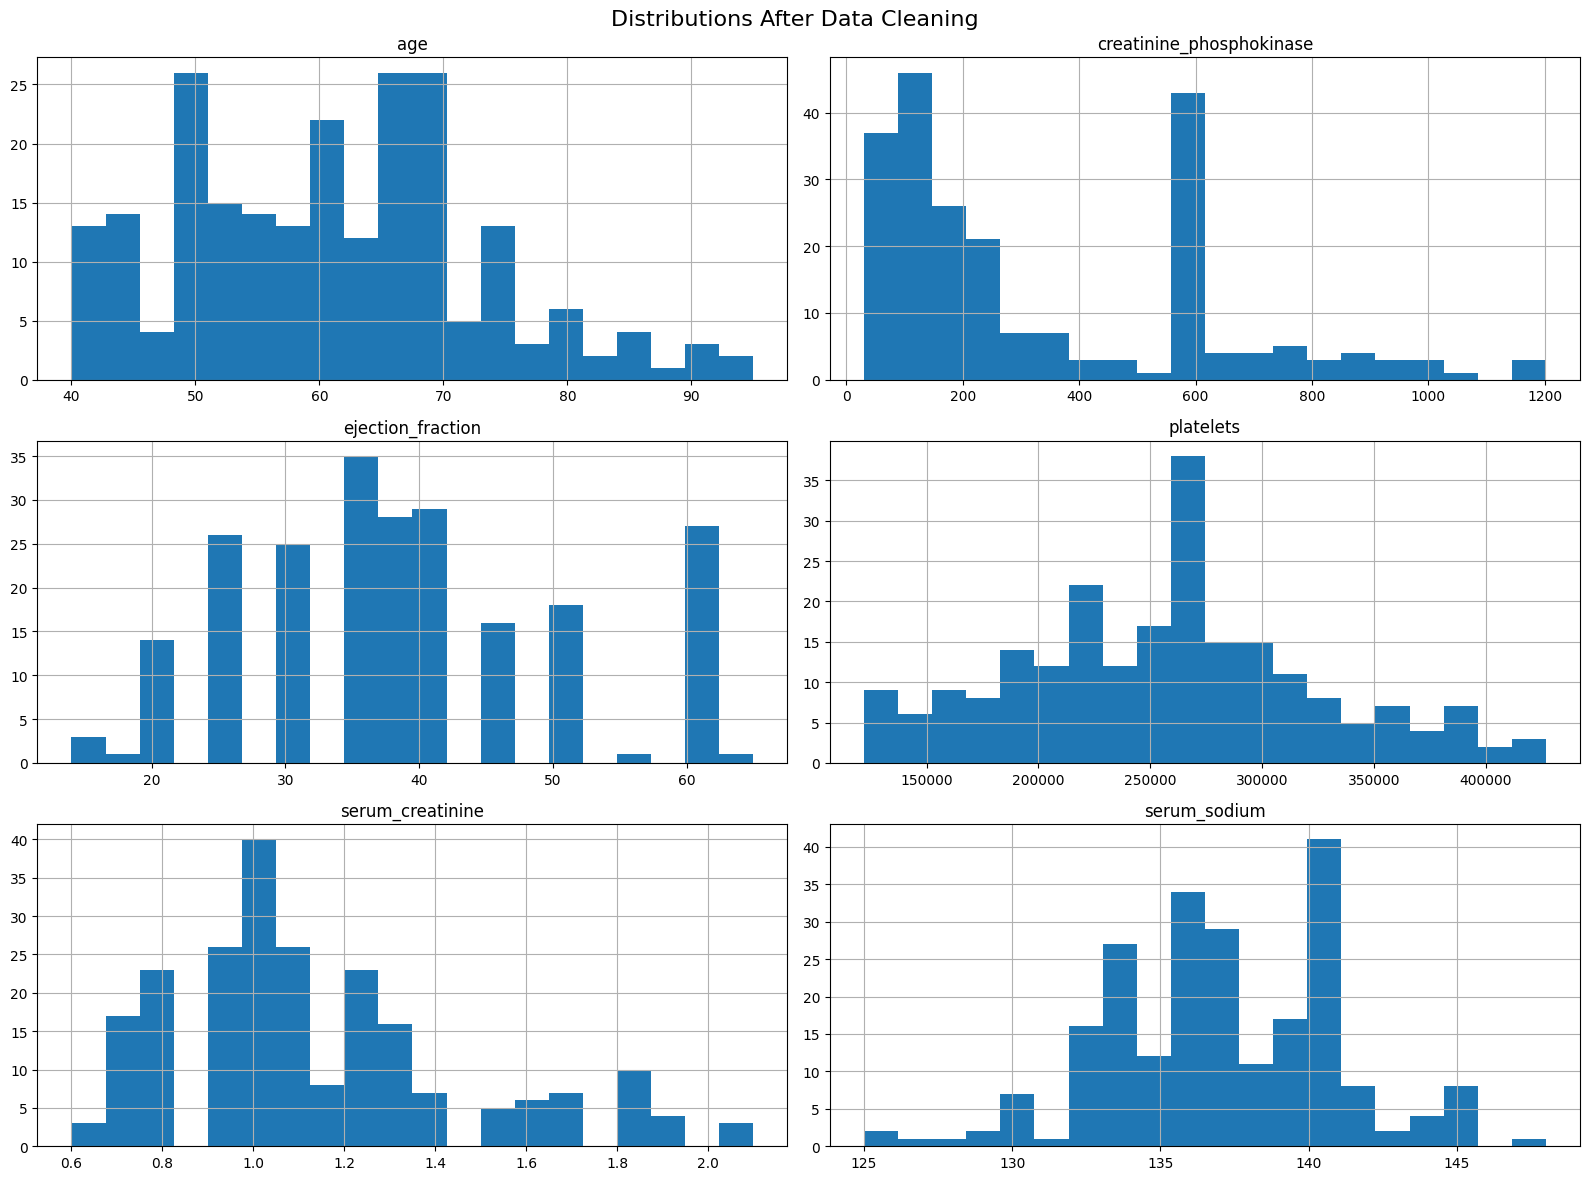

In [18]:
cleaned_df[comparison_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distributions After Data Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

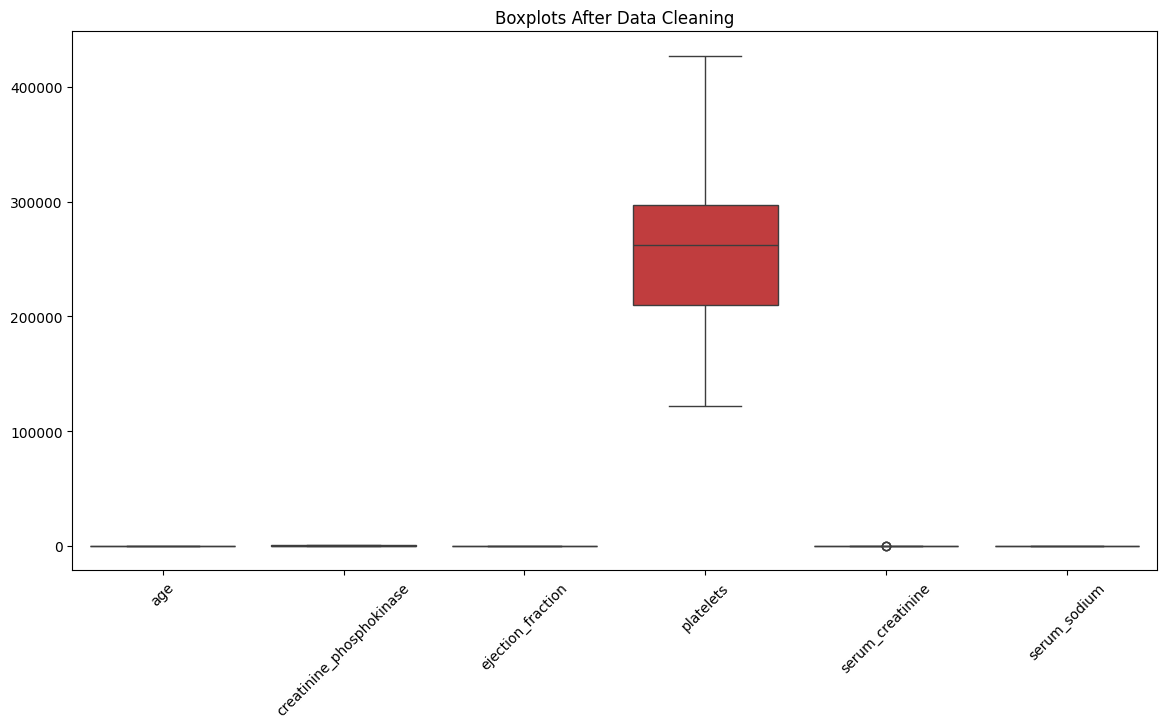

In [19]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=cleaned_df[comparison_columns])

plt.title("Boxplots After Data Cleaning")
plt.xticks(rotation=45)
plt.show()

In [20]:

missing_values = cleaned_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:",
      missing_values.sum())
print("Total missing values after encoding and normalization:",
      encoded_df.isnull().sum().sum())

Missing values in each column:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score                  0
dtype: int64

Total missing values: 0
Total missing values after encoding and normalization: 0


In [21]:
print("Final dataset shape:", encoded_df.shape)

display(encoded_df.head())

print("\nFinal dataset information:")
encoded_df.info()

Final dataset shape: (224, 18)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,time,DEATH_EVENT,risk_score,sex_0,sex_1,smoking_0,smoking_1,age_group_40-60,age_group_>60
0,0.636364,0,0.470990,0,0.117647,1,0.468852,0.866667,0.217391,0.000000,1,0.310545,0,1,1,0,0,1
2,0.454545,0,0.098976,0,0.117647,0,0.131148,0.466667,0.173913,0.010676,1,0.171495,0,1,0,1,0,1
3,0.181818,1,0.069113,0,0.117647,0,0.288525,0.866667,0.521739,0.010676,1,0.310545,0,1,1,0,1,0
5,0.909091,1,0.014505,0,0.509804,1,0.268852,1.000000,0.304348,0.014235,1,0.843569,0,1,0,1,0,1
6,0.636364,1,0.184300,0,0.019608,0,0.016393,0.400000,0.521739,0.021352,1,0.078795,0,1,1,0,0,1



Final dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 224 entries, 0 to 298
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       224 non-null    float64
 1   anaemia                   224 non-null    int64  
 2   creatinine_phosphokinase  224 non-null    float64
 3   diabetes                  224 non-null    int64  
 4   ejection_fraction         224 non-null    float64
 5   high_blood_pressure       224 non-null    int64  
 6   platelets                 224 non-null    float64
 7   serum_creatinine          224 non-null    float64
 8   serum_sodium              224 non-null    float64
 9   time                      224 non-null    float64
 10  DEATH_EVENT               224 non-null    int64  
 11  risk_score                224 non-null    float64
 12  sex_0                     224 non-null    int64  
 13  sex_1                     224 non-null    

In [22]:
encoded_df.to_csv(
    "heart_failure_cleaned_dataset.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
